# Análise Exploratória de Dados (EDA) - SSP-SP
**Objetivo da Sprint 1:** Validar a completude e qualidade dos dados espaciais (Latitude e Longitude) e temporais dos furtos de veículos na base de São Paulo para garantir a viabilidade da malha geoespacial.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Carregamento da Amostra de Dados
Vamos carregar as amostras extraídas do robô (ex: Janeiro e Fevereiro de 2023) para verificar a consistência dos dados brutos. Os dados da SSP vêm num formato tabular do Excel/CSV.


In [2]:
import glob

# Encontra os arquivos raw baixados
files = glob.glob('../data/SP/raw/FURTO_VEICULO_2023_*.xls')
print(f"Arquivos encontrados: {files}")

# Como o formato da SSP-SP costuma usar delimitador tab mesmo sendo salvo como .xls,
# é mais seguro tentar ler como CSV com separador 	, mas usando engine python se falhar.
# O pandas read_excel falha se o arquivo for um falso .xls (que na verdade é HTML ou TSV).
# Vamos forçar a leitura do primeiro arquivo para espiar o formato.

df_list = []
for file in files:
    try:
        # A SSP envia como utf-16le ou iso-8859-1 com tabulações na maioria das vezes
        df_temp = pd.read_csv(file, sep='\t', encoding='utf-16le')
        df_list.append(df_temp)
    except Exception as e:
        print(f"Falha ao ler {file} com utf-16: {e}")
        try:
            df_temp = pd.read_csv(file, sep='\t', encoding='iso-8859-1')
            df_list.append(df_temp)
        except Exception as e2:
            print(f"Falha ao ler {file} com iso-8859-1: {e2}")

if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print(f"Total de registros carregados: {df.shape[0]}")
    display(df.head())
else:
    print("Nenhum arquivo carregado com sucesso.")


Arquivos encontrados: ['../data/SP/raw/FURTO_VEICULO_2023_12.xls', '../data/SP/raw/FURTO_VEICULO_2023_07.xls', '../data/SP/raw/FURTO_VEICULO_2023_03.xls', '../data/SP/raw/FURTO_VEICULO_2023_01.xls', '../data/SP/raw/FURTO_VEICULO_2023_09.xls', '../data/SP/raw/FURTO_VEICULO_2023_11.xls', '../data/SP/raw/FURTO_VEICULO_2023_05.xls', '../data/SP/raw/FURTO_VEICULO_2023_04.xls', '../data/SP/raw/FURTO_VEICULO_2023_06.xls', '../data/SP/raw/FURTO_VEICULO_2023_10.xls', '../data/SP/raw/FURTO_VEICULO_2023_08.xls', '../data/SP/raw/FURTO_VEICULO_2023_02.xls']


/tmp/ipykernel_31286/3621408588.py:16: DtypeWarning: Columns (0: TIPOPESSOA, 1: VITIMAFATAL, 2: SEXO, 3: DATANASCIMENTO, 4: ESTADOCIVIL, 5: PROFISSAO, 6: GRAUINSTRUCAO, 7: NATUREZAVINCULADA, 8: TIPOVINCULO) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, sep='\t', encoding='utf-16le')
/tmp/ipykernel_31286/3621408588.py:16: DtypeWarning: Columns (0: DESDOBRAMENTO, 1: TIPOPESSOA, 2: VITIMAFATAL, 3: NACIONALIDADE, 4: SEXO, 5: DATANASCIMENTO, 6: ESTADOCIVIL, 7: PROFISSAO, 8: GRAUINSTRUCAO, 9: NATUREZAVINCULADA, 10: TIPOVINCULO) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, sep='\t', encoding='utf-16le')
/tmp/ipykernel_31286/3621408588.py:16: DtypeWarning: Columns (0: TIPOPESSOA, 1: VITIMAFATAL, 2: NATURALIDADE, 3: NACIONALIDADE, 4: SEXO, 5: DATANASCIMENTO, 6: ESTADOCIVIL, 7: PROFISSAO, 8: GRAUINSTRUCAO, 9: NATUREZAVINCULADA, 10: TIPOVINCULO) have mixed types. Specify dtype opti

Falha ao ler ../data/SP/raw/FURTO_VEICULO_2023_02.xls com utf-16: Error tokenizing data. C error: EOF inside string starting at row 11844
Total de registros carregados: 194730


,ANO_BO,NUM_BO,NUMERO_BOLETIM,BO_INICIADO,BO_EMITIDO,DATAOCORRENCIA,HORAOCORRENCIA,PERIDOOCORRENCIA,DATACOMUNICACAO,DATAELABORACAO,...,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53
0,2023.0,1962806.0,1962806/2023,01/12/2023 00:00:40,01/12/2023 00:00:47,30/11/2023,20:31,A NOITE,30/11/2023,01/12/2023 00:00:40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023.0,1962807.0,1962807/2023,01/12/2023 00:03:11,01/12/2023 00:03:16,30/11/2023,21:00,A NOITE,30/11/2023,01/12/2023 00:03:11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023.0,1962810.0,1962810/2023,01/12/2023 00:04:34,01/12/2023 00:04:39,30/11/2023,21:30,A NOITE,30/11/2023,01/12/2023 00:04:34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023.0,1962811.0,1962811/2023,01/12/2023 00:06:58,01/12/2023 00:07:04,30/11/2023,21:40,A NOITE,30/11/2023,01/12/2023 00:06:58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023.0,6351.0,6351/2023,01/12/2023 00:08:32,01/12/2023 00:08:32,30/11/2023,17:10,A TARDE,30/11/2023,01/12/2023 00:08:32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Validação da Qualidade Espacial (Lat/Long)
Modelos de previsão criminal dependem absurdamente da qualidade do preenchimento das coordenadas. Se muitos BOs vierem com Lat/Long nulos, o georreferenciamento para a malha H3 falhará.


Colunas espaciais encontradas: ['LATITUDE', 'LONGITUDE']
Registros com Latitude nula: 37651 (19.33%)


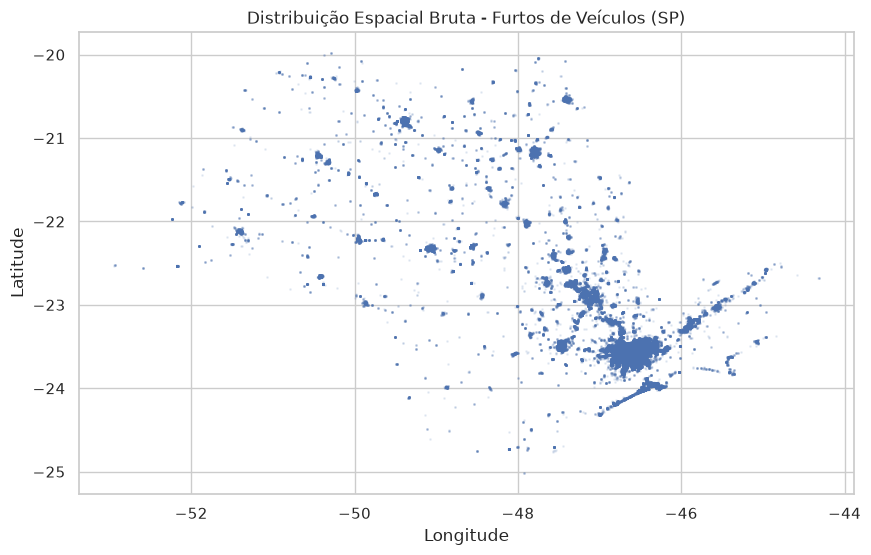

In [3]:
if 'df' in locals():
    cols_espaciais = [col for col in df.columns if 'LATITUDE' in col or 'LONGITUDE' in col]
    print(f"Colunas espaciais encontradas: {cols_espaciais}")
    
    if cols_espaciais:
        lat_col = cols_espaciais[0]
        lon_col = cols_espaciais[1]
        df[lat_col] = pd.to_numeric(df[lat_col].astype(str).str.replace(',', '.'), errors='coerce')
        df[lon_col] = pd.to_numeric(df[lon_col].astype(str).str.replace(',', '.'), errors='coerce')
        
        nulos_lat = df[lat_col].isna().sum()
        pct_nulos = (nulos_lat / len(df)) * 100
        
        print(f"Registros com Latitude nula: {nulos_lat} ({pct_nulos:.2f}%)")
        
        # Filtra os dados válidos
        df_geo = df.dropna(subset=[lat_col, lon_col])
        
        plt.scatter(df_geo[lon_col], df_geo[lat_col], alpha=0.1, s=1)
        plt.title('Distribuição Espacial Bruta - Furtos de Veículos (SP)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.show()
    else:
        print("Atenção: Colunas de latitude/longitude não encontradas no dataset!")


## 3. Validação Temporal (Data e Hora)
Devemos separar a Data do Registro Administrativo da Data Real do Fato (DATAOCORRENCIA). O crime de furto frequentemente tem um atraso na notificação (delay de BO), o que precisamos mapear.


Colunas de data encontradas: ['DATAOCORRENCIA', 'DATACOMUNICACAO', 'DATAELABORACAO', 'DATANASCIMENTO']
Ocorrências com data válida: 181040


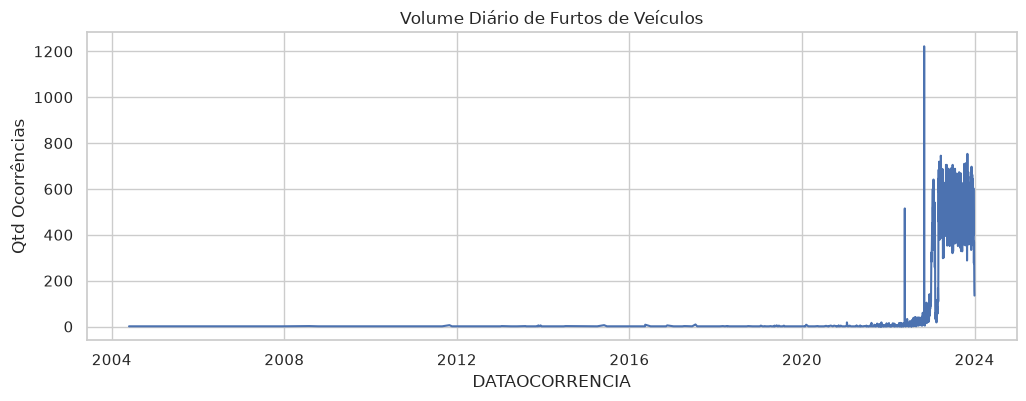

In [4]:
if 'df' in locals():
    # Identifica colunas de tempo
    cols_data = [col for col in df.columns if 'DATA' in col]
    print(f"Colunas de data encontradas: {cols_data}")
    
    if 'DATAOCORRENCIA' in df.columns:
        df['DATAOCORRENCIA'] = pd.to_datetime(df['DATAOCORRENCIA'], errors='coerce', dayfirst=True)
        
        # Quantidade de dias válidos
        print(f"Ocorrências com data válida: {df['DATAOCORRENCIA'].notna().sum()}")
        
        df['DATAOCORRENCIA'].dt.date.value_counts().sort_index().plot(figsize=(12,4))
        plt.title('Volume Diário de Furtos de Veículos')
        plt.ylabel('Qtd Ocorrências')
        plt.show()
